# AMI Deconvolutions


In [ ]:
import os
import jax
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [ ]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana2/snert/max/data/amigo_files/"
    data_path = "/media/morgana2/snert/max/data/JWST/NGC1068/calslope/"
else:
    cache = "/Volumes/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/NGC1068/calslope/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/NGC1068/")

state = np.load(
    os.path.join(model_cache, "ode/test_state.npy"), allow_pickle=True
).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [ ]:
# Build the ramp model
n_latent = 6
keys = jr.split(jr.PRNGKey(0), 3)
encoder = amigo.latent_ode_models.LatentEncoder(
    n_latent=n_latent, width=6, depth=2, key=keys[0], pools=[0, 1]
)
latent_ode = amigo.latent_ode_models.LatentODE(
    n_latent=n_latent, width=3, depth=2, key=keys[1]
)
decoder = amigo.latent_ode_models.LatentDecoder(
    n_latent=n_latent, depth=3, key=keys[2], up_samples=[1, 2], out_channels=2
)

# ramp = LatentODERamp(encoder=encoder, latent_ode=latent_ode, decoder=decoder)
ode_ramp = amigo.latent_ode_models.GainDiffusionRamp(
    encoder=encoder, latent_ode=latent_ode, decoder=decoder
)

# Loading in data

In [ ]:
files = file_fn(data_path)

# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
dorito.misc.truncate_files(sci_files, 4)

In [ ]:
source_size = 120
shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
wavelets = dorito.build_model.wavelet_prior(source_size)

model, params, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    # cal_files[0:3],
    # sci_files[0:2],
    # cal_files,
    [],
    sci_files,
    # [],
    state=state,
    # width=width,
    # depth=depth,
    ramp_model=ode_ramp,
    extra_priors={
        # "wavelets": shearlets,
        # "wavelets": wavelets,
        "log_distribution": np.log10(
            np.ones((source_size, source_size)) / source_size**2
        ),
        "spectral_coeffs": np.array([1.0, 0.0]),
    },
    # shearletSystem=shearletSystem,
    sci_fit=dorito.model_fits.ResolvedFit,
    Teff_cache=teff_cache,
    separate_fits=True,
)
fits = [*cal_fits, *sci_fits]

# init state
init_state = np.load(init_state_cache + "F480M_120.npy", allow_pickle=True)[()]
for p in [
    "positions",
    "fluxes",
    "aberrations",
    "log_distribution",
]:
    params[p] = init_state[p]
model = model.set("params", params)

model = model.set("FF", np.ones_like(model.FF))

In [ ]:
for fs in [sci_fits, cal_fits]:
    print(f"{len(fs)} Files:")
    for f in fs:

        img = np.where(f.badpix, np.nan, f.ramp[-1])

        print(
            f"\
            TARG: {f.star}\
            FILTER: {f.filter}\
            NGROUPS: {f.ngroups}\
            PEAK: {int(np.nanmax(img))}, {np.nanmax(img) / 2**16 :.1%} sat. \
        "
        )
    print()

for fs in [sci_fits, cal_fits]:
    print(f"{len(fs)} Files:")

    for f in fs:
        grps = np.array([np.where(f.badpix, np.nan, grp) for grp in f.ramp])
        top = grps[-1]
        print(
            f"\
            TARG: {f.star}\
            FILTER: {f.filter}\
            NGROUPS: {f.ngroups}\
            PEAK: {int(np.nanmax(top))}, {np.nanmax(top) / 2**16 :.1%} sat. \
        "
        )

        for i, grp in enumerate(grps):
            print(
                f"GROUP {i}, PEAK: {int(np.nanmax(grp))}, {np.nanmax(grp) / 2**16 :.1%} sat."
            )
        # print(f"PEAK: {int(np.nanmax(img))}, {np.nanmax(img) / 2**16 :.1%} sat.")
        print()

In [ ]:
plt.subplots(2, 3, figsize=(10, 5))

for i in [0, -1]:
    fit = fits[i]
    slope = fits[i].slopes[-1]
    ramp = fits[i].ramp[-1]
    badpix = fits[i].badpix
    ppcount = np.nanmax(np.where(badpix, np.nan, ramp))

    print(fit.filter)

    x = np.where(badpix, np.nan, slope)
    plt.subplot(2, 3, 3 * abs(i) + 1)
    plt.imshow(x, cmap=inferno, norm=mpl.colors.PowerNorm(0.5))
    plt.title(f"{fits[i].star}, Peak: {int(ppcount)}")
    plt.colorbar()

    init_slopes = fit(model)
    plt.subplot(2, 3, 3 * abs(i) + 2)
    plt.imshow(init_slopes[-1], cmap=inferno, norm=mpl.colors.PowerNorm(0.5))
    plt.title(f"{fits[i].star}, Init Model")
    plt.colorbar()

    plt.subplot(2, 3, 3 * abs(i) + 3)
    plt.imshow(x - init_slopes[-1], cmap=seismic, norm=mpl.colors.CenteredNorm())
    plt.title(f"Residuals")
    plt.colorbar()


plt.tight_layout()
plt.show()

In [ ]:
# for grp, slope in zip(exposures[1].ramp[1:], exposures[1].slopes):

#     img = np.where(exposures[1].badpix, np.nan, grp)
#     slop = np.where(exposures[1].badpix, np.nan, slope)
#     print()

#     plt.figure(figsize=(3, 1))

#     plt.subplot(1, 2, 1)
#     plt.imshow(img)
#     plt.axis("off")
#     plt.title(f"Peak: {int(np.nanmax(img))}")
#     plt.colorbar()

#     plt.subplot(1, 2, 2)
#     plt.imshow(slop)
#     plt.axis("off")
#     plt.colorbar()

#     plt.tight_layout()
#     plt.show()

In [ ]:
fisher_params = [
    "positions",
    "fluxes",
    "aberrations",
    # "one_on_fs",
    # "log_distribution",
    "spectral_coeffs",
]

fishers = amigo.fisher.calc_fishers(
    model.set("ramp", None),
    fits,
    # sci_exposures,
    fisher_params,
    overwrite=True,
    cache=fisher_cache,
    recalculate=False,
)

THIS IS HAPPENING BECAUSE THE SAVED STATE WAS WHEN I WAS USING THE WRONG NORMALISATION FUNCTION

In [22]:
n_epoch = 400

config = {
    # "positions": sgd(2e-1, 0),
    # "fluxes": sgd(5e-1, 2),
    # "aberrations": sgd(5e-2, 4),
    # "log_distribution": adam(2e-2, 7),  # , (10, 0.25), b1=0.7),
    "positions": sgd(2e-2, 5),
    "fluxes": sgd(2e-2, 0),
    "log_distribution": adam(2e-2, 0),  # , (10, 0.25), b1=0.7),
    # "one_on_fs": sgd(1e2, 6),
    # "wavelets": adam(5e-5, 0),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    # "L1": 1.0e-3,
    # "L1": 5.0e-4,
    # "L2": None,
    # "TV": None,
    "QV": 1.0e-3,
    # "ME": None,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {"L1": dorito.stats.L1_on_wavelets, "QV": dorito.stats.TSV},
}
final_model, losses, state, histories = amigo.fitting.optimise(
    model,
    # pds_sci_exposures,
    fits,
    fishers=fishers,
    optimisers=config,
    args=args,
    # norm_fn=dorito.stats.normalise_wavelets,
    norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    epochs=n_epoch,
    print_grads=False,
    eps=1e-3,
)

balance = dorito.stats.prior_data_balance(final_model, fits[-1], args)
print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/400 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:17
Initial Loss: 2,929.99
Est time per epoch:  0:00:01
Est run time:  0:08:04


KeyboardInterrupt: 

In [ ]:
# break
sweep, coeffs, log_dists = dorito.stats.lcurve_sweep(
    "QV",
    # coeffs=np.logspace(0, 10, 11),
    coeffs=[1e-3,]
    model=model,
    exposures=fits,
    args=args,
    optimisers=config,
    fishers=fishers,
    # args=args,
    norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    # loss_fn=zdx.combine,
    # epochs=n_epoch,
    epochs=400,
    print_grads=False,
    eps=1e-3,
)

In [ ]:
for i, l in enumerate(log_dists):
    plt.imshow(10 ** l["F480M"], norm=mpl.colors.PowerNorm(0.5), cmap="afmhot_10u")
    plt.title(f"{coeffs[i]:.3e}")
    plt.colorbar()
    plt.show()

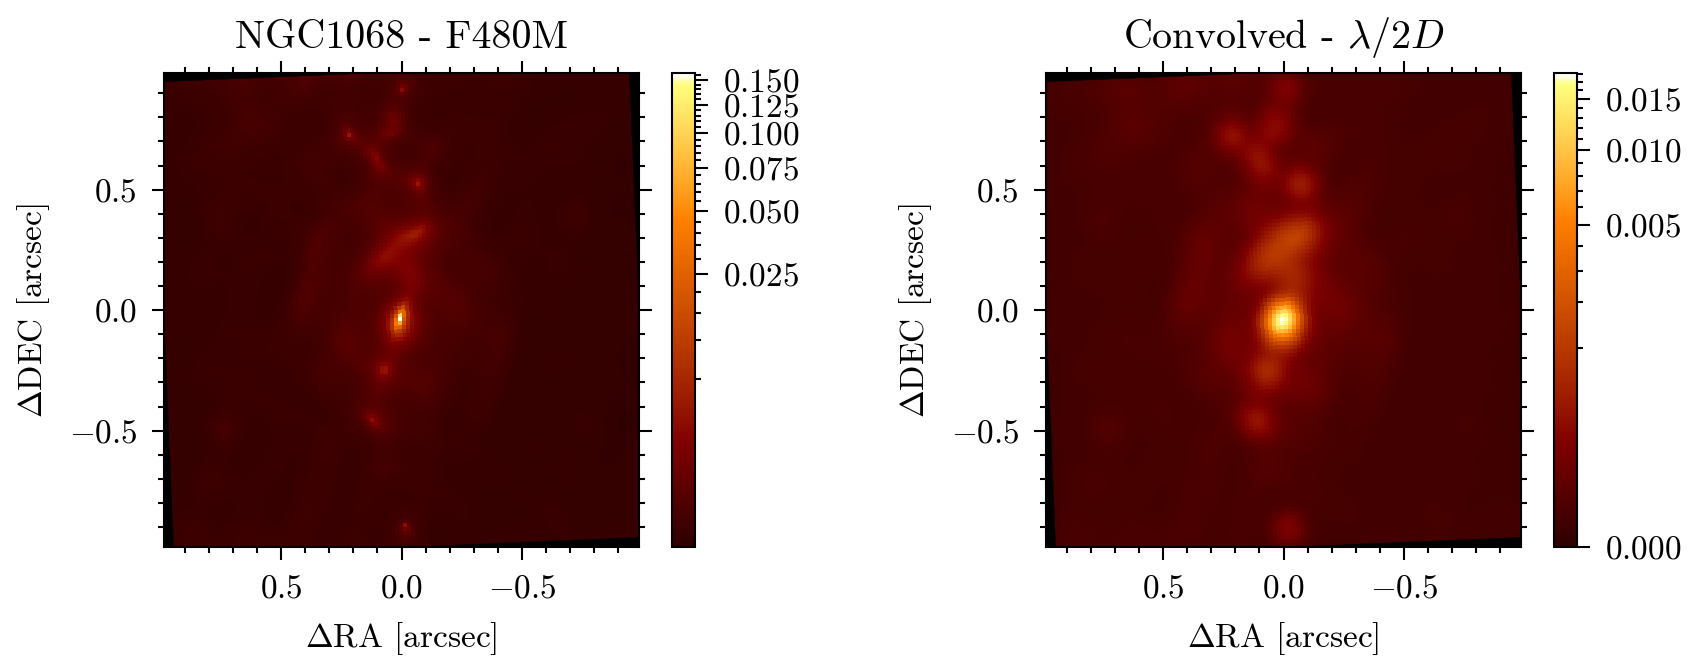

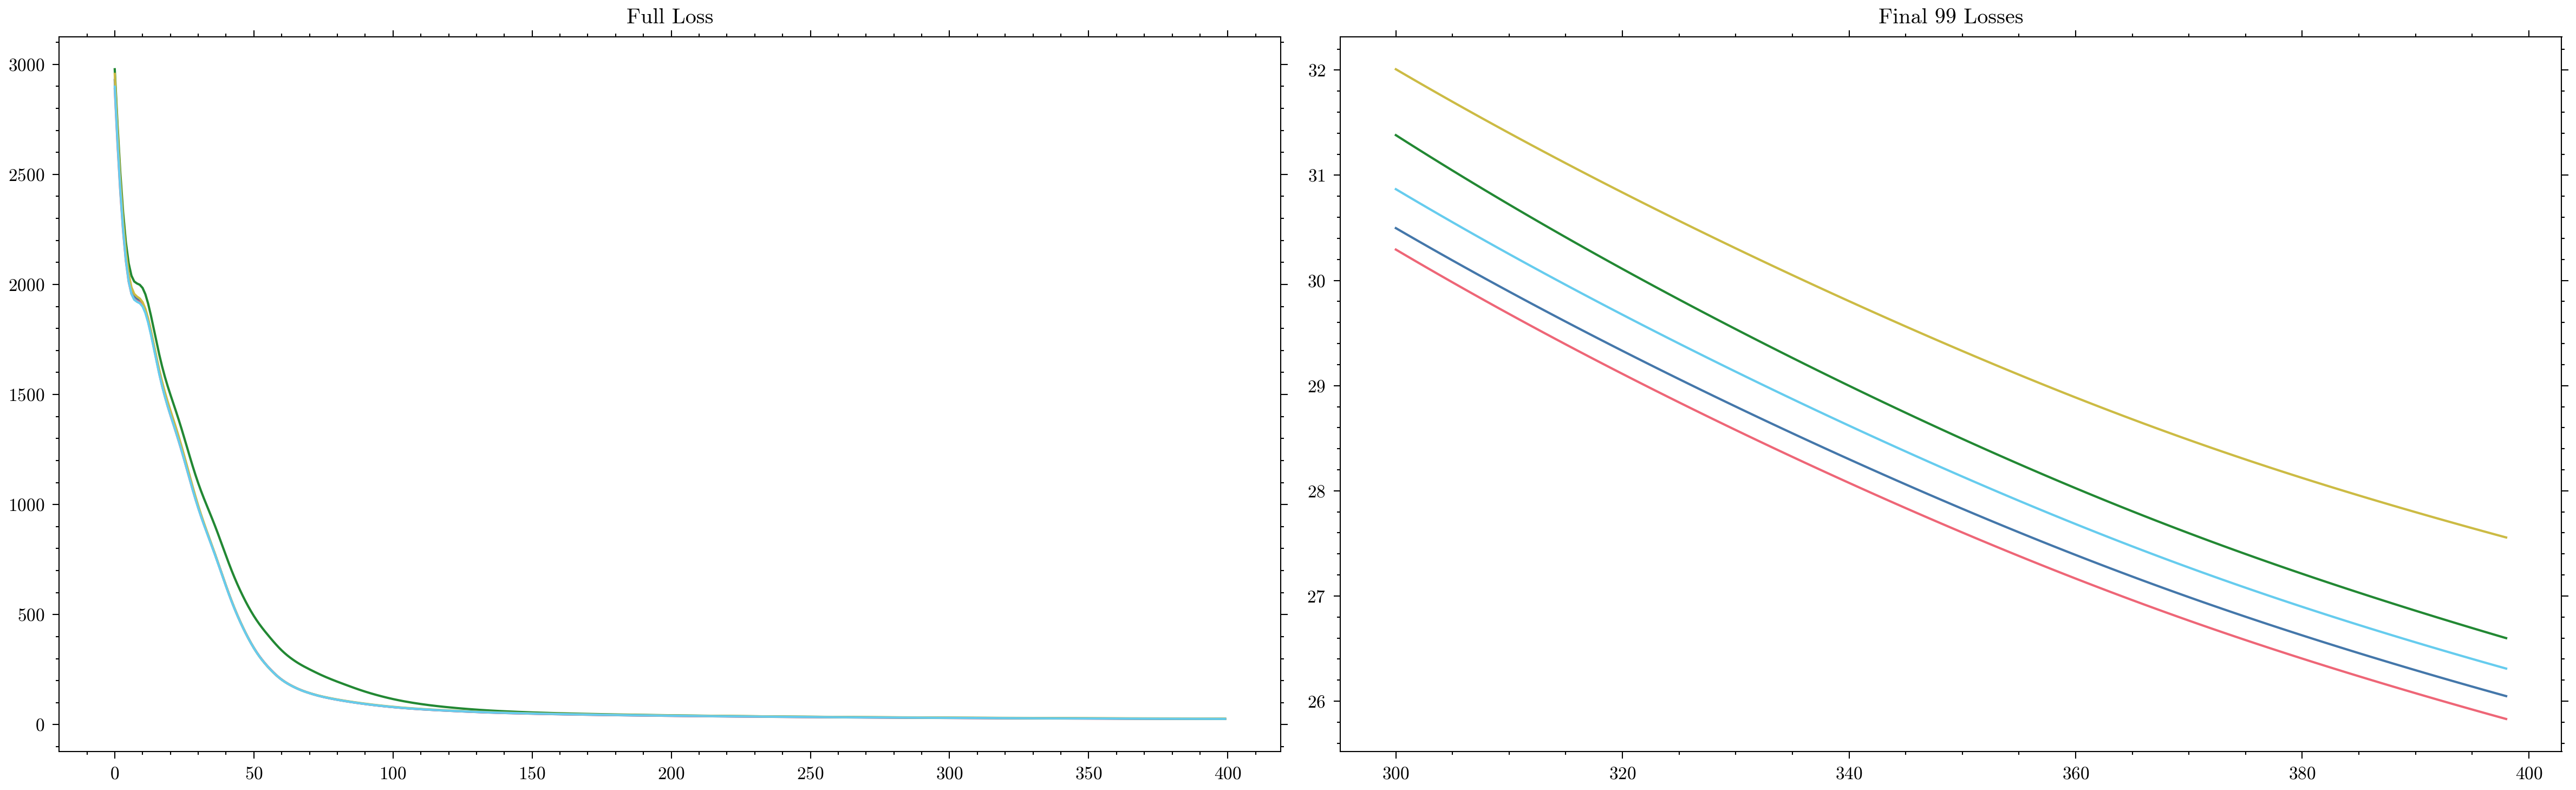

No formatting function for log_distribution


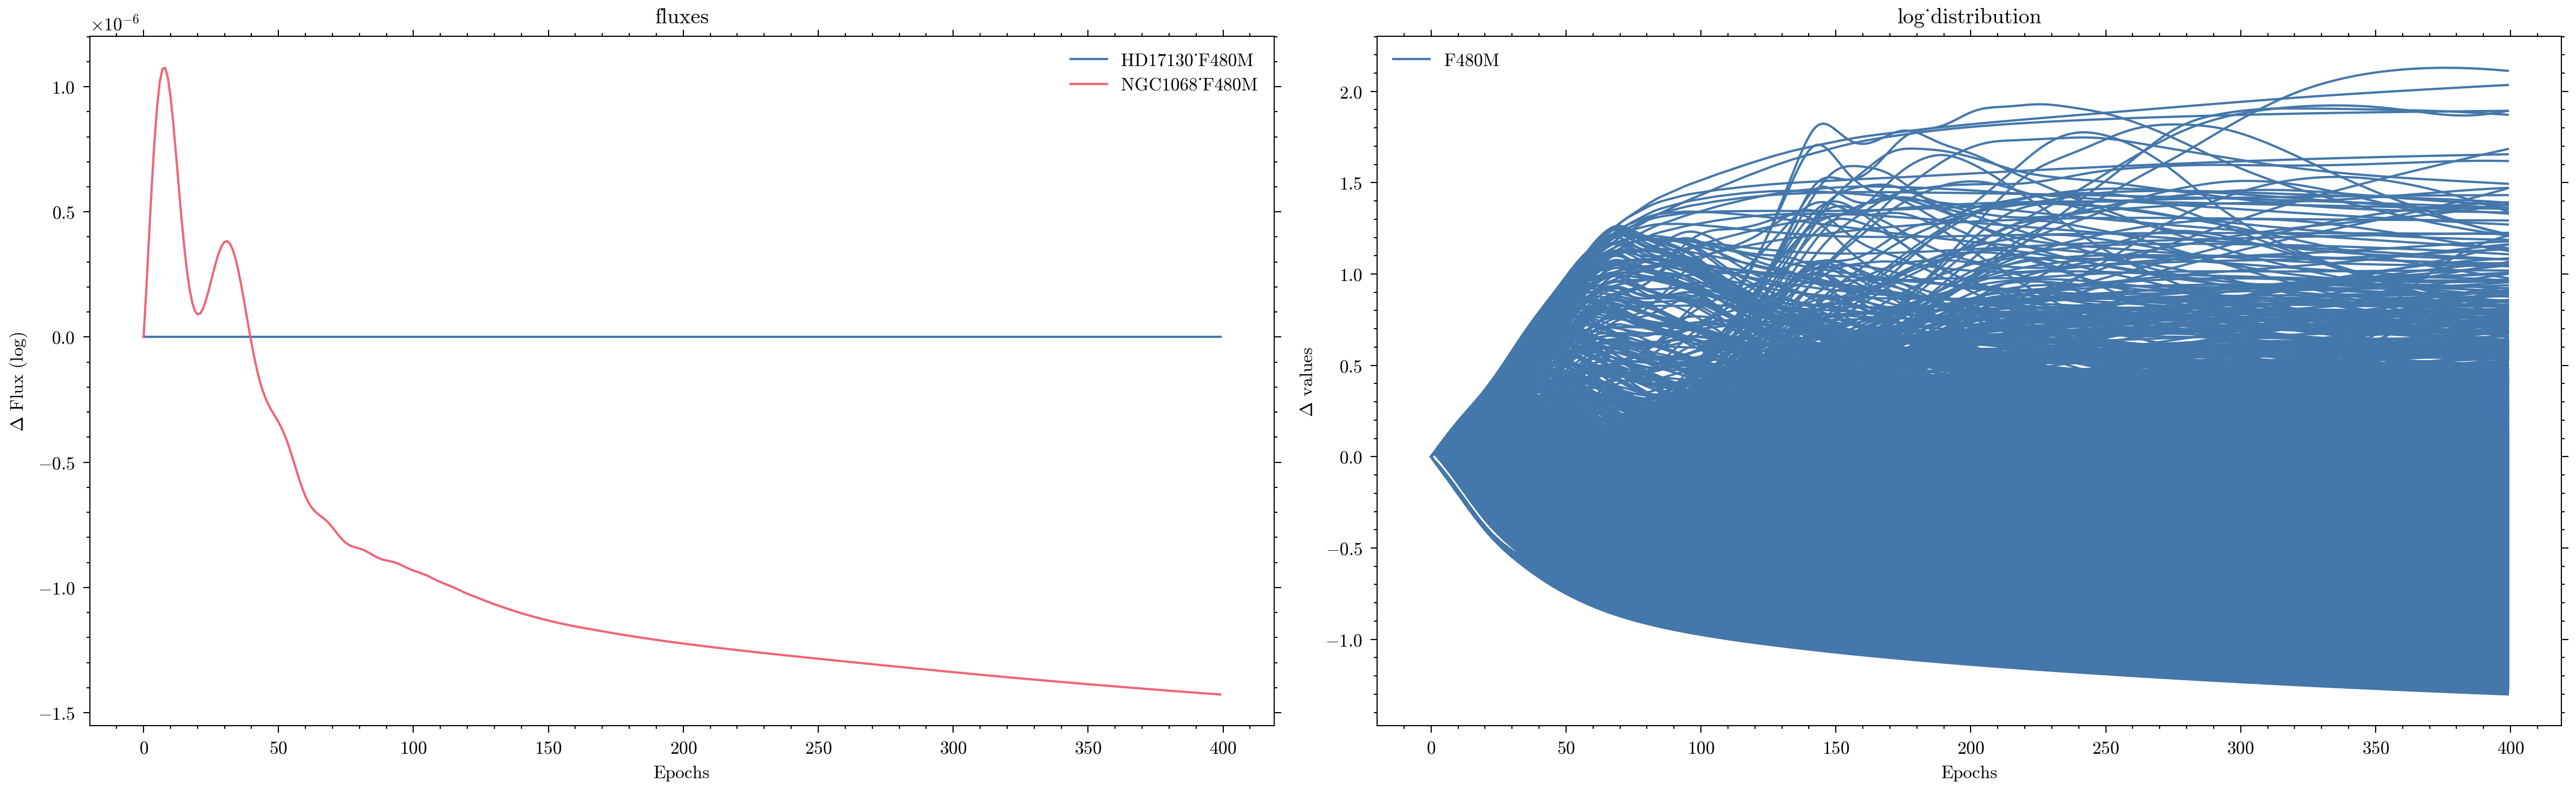

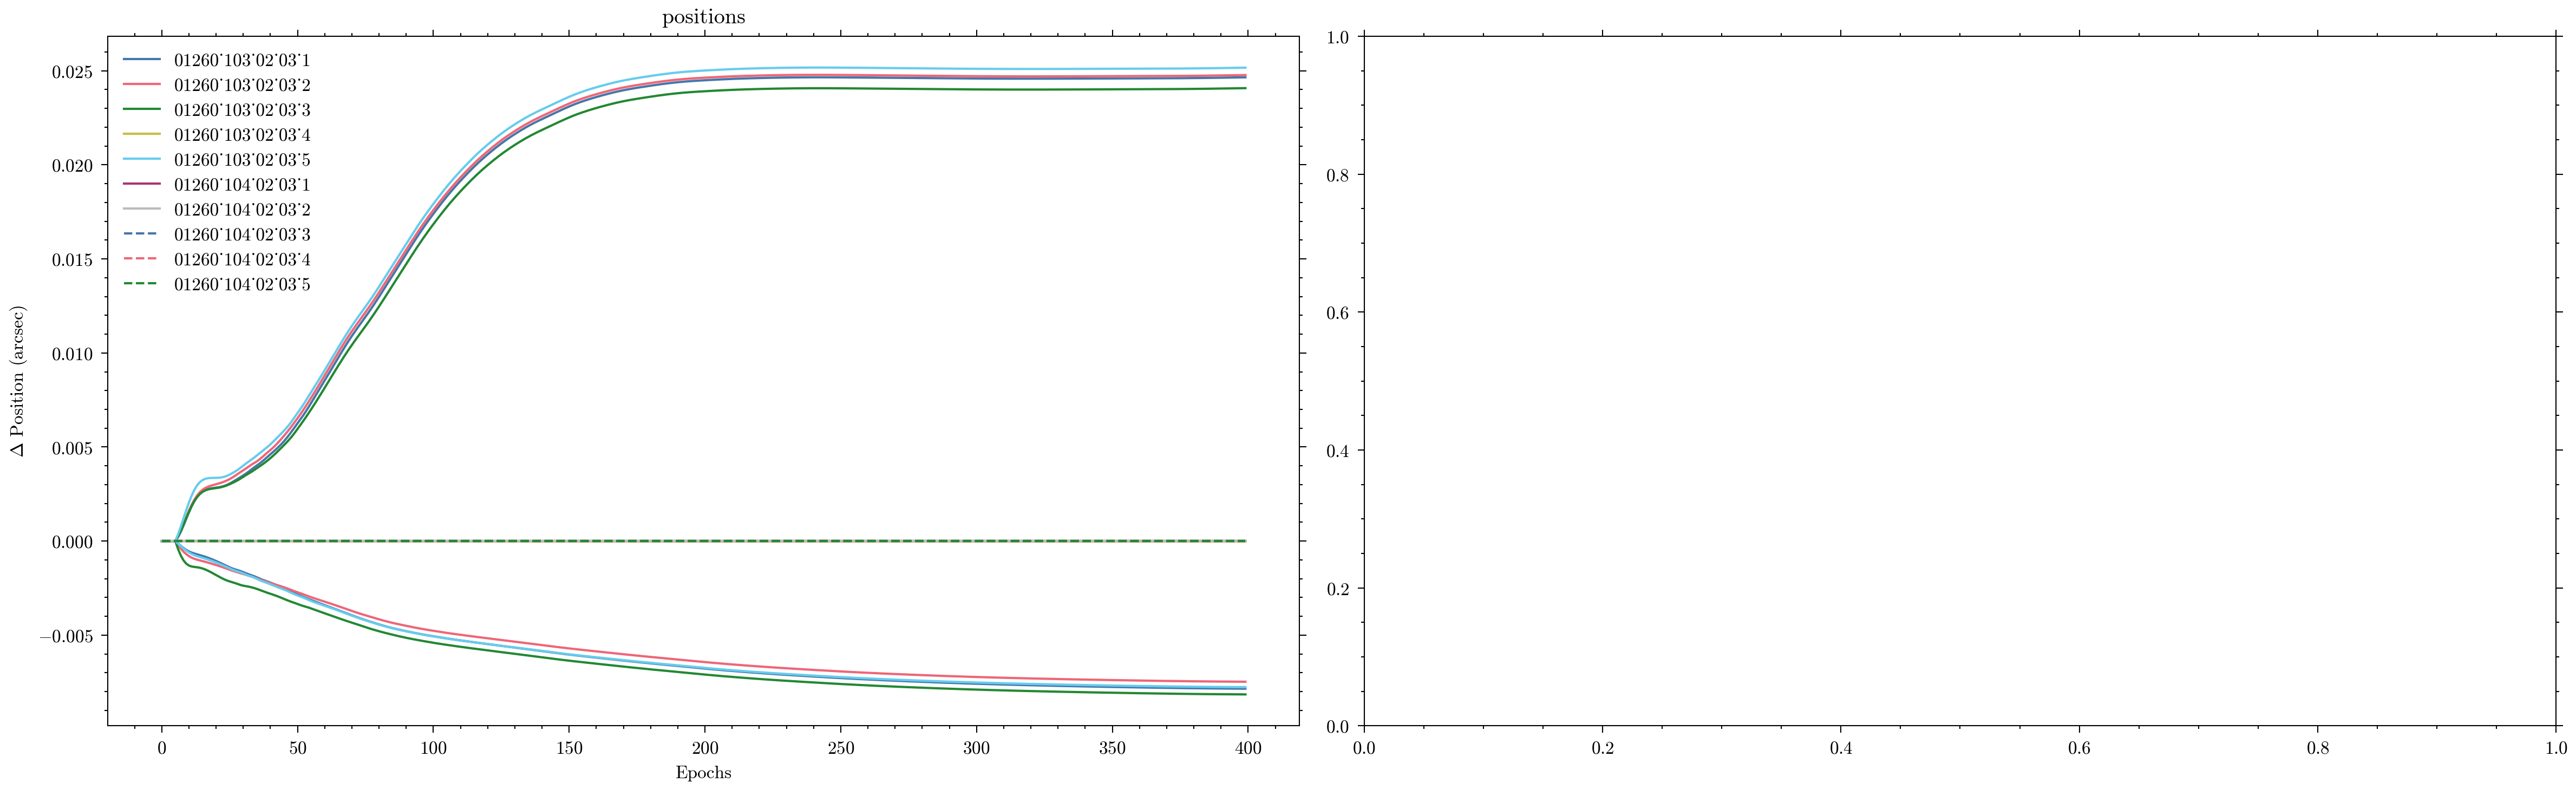

File 01260_103_02_03_5
Star NGC1068
Filter F480M
nints 91
ngroups 4



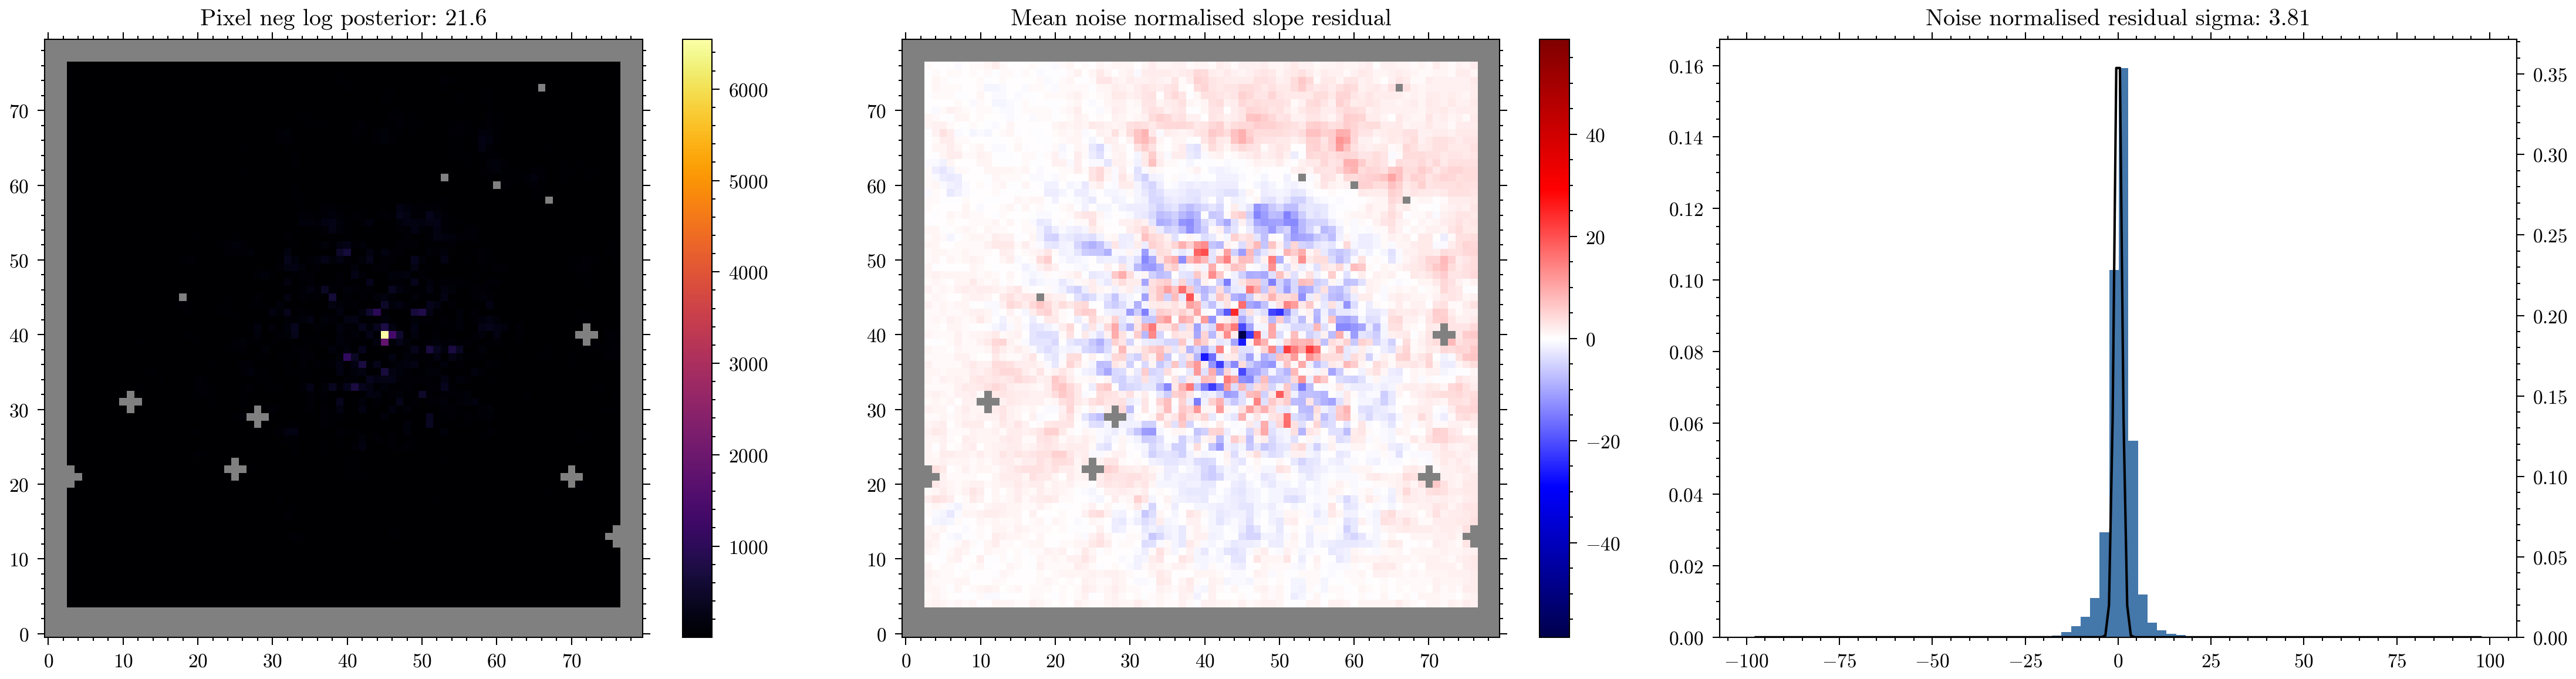

File 01260_103_02_03_2
Star NGC1068
Filter F480M
nints 91
ngroups 4



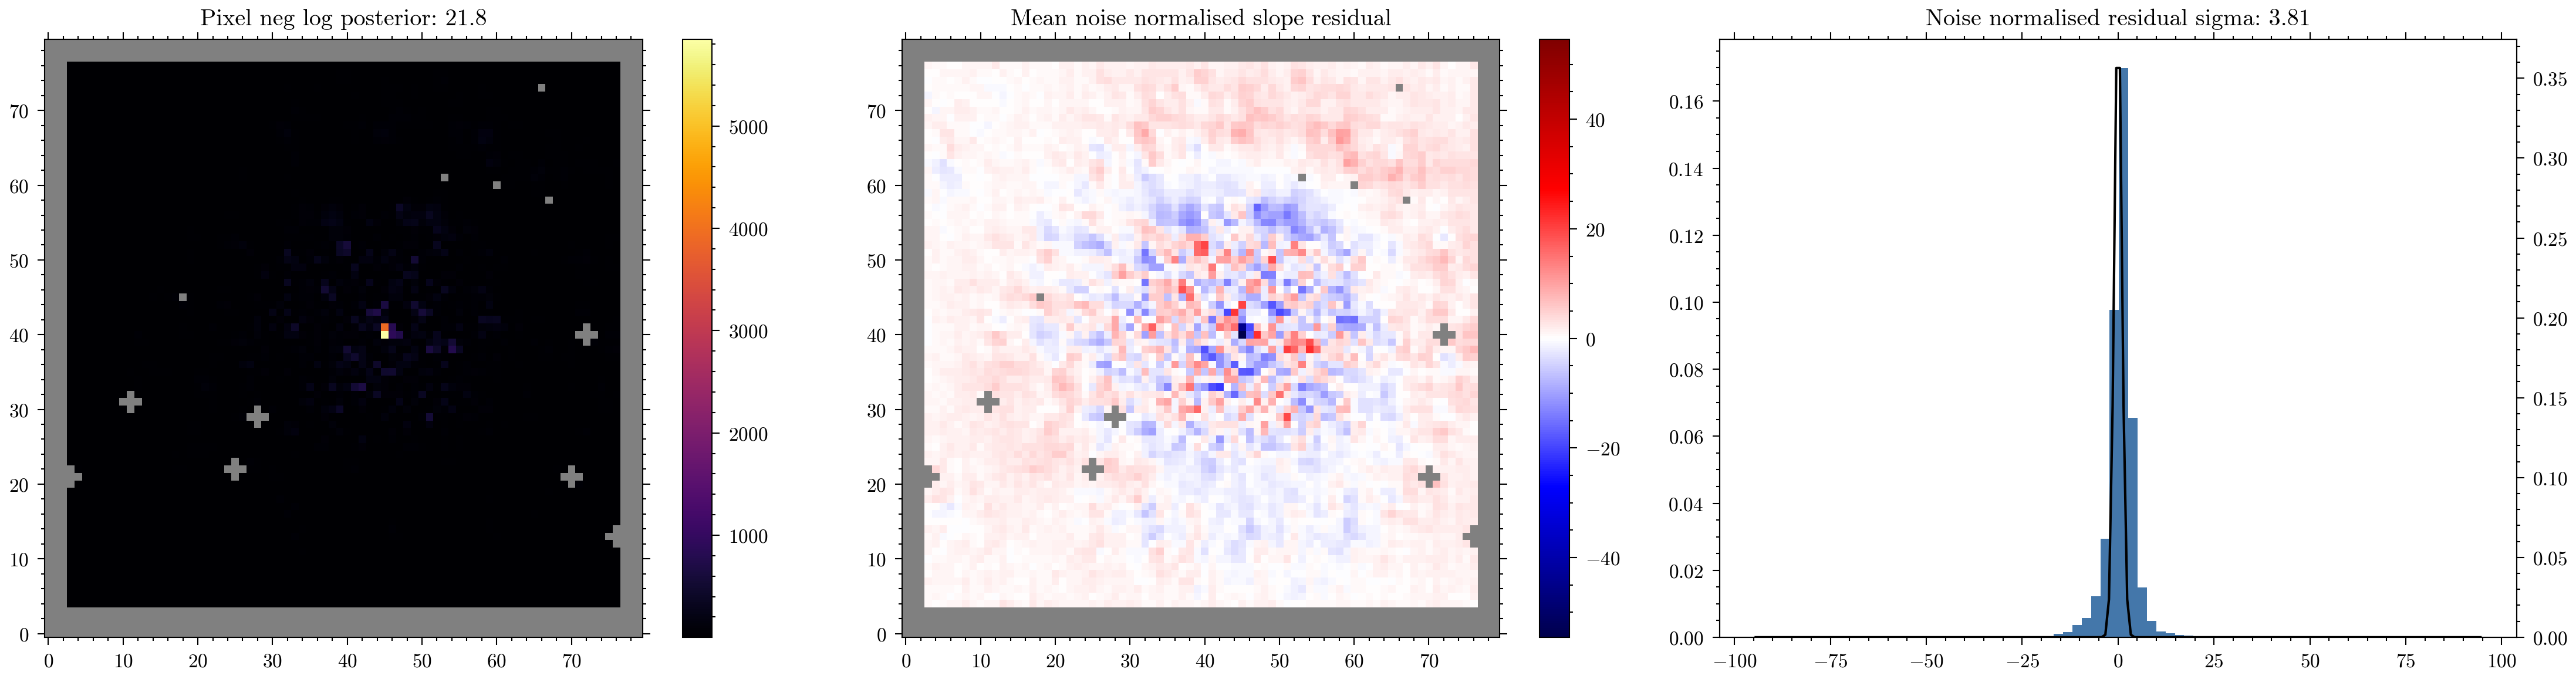

File 01260_103_02_03_1
Star NGC1068
Filter F480M
nints 91
ngroups 4



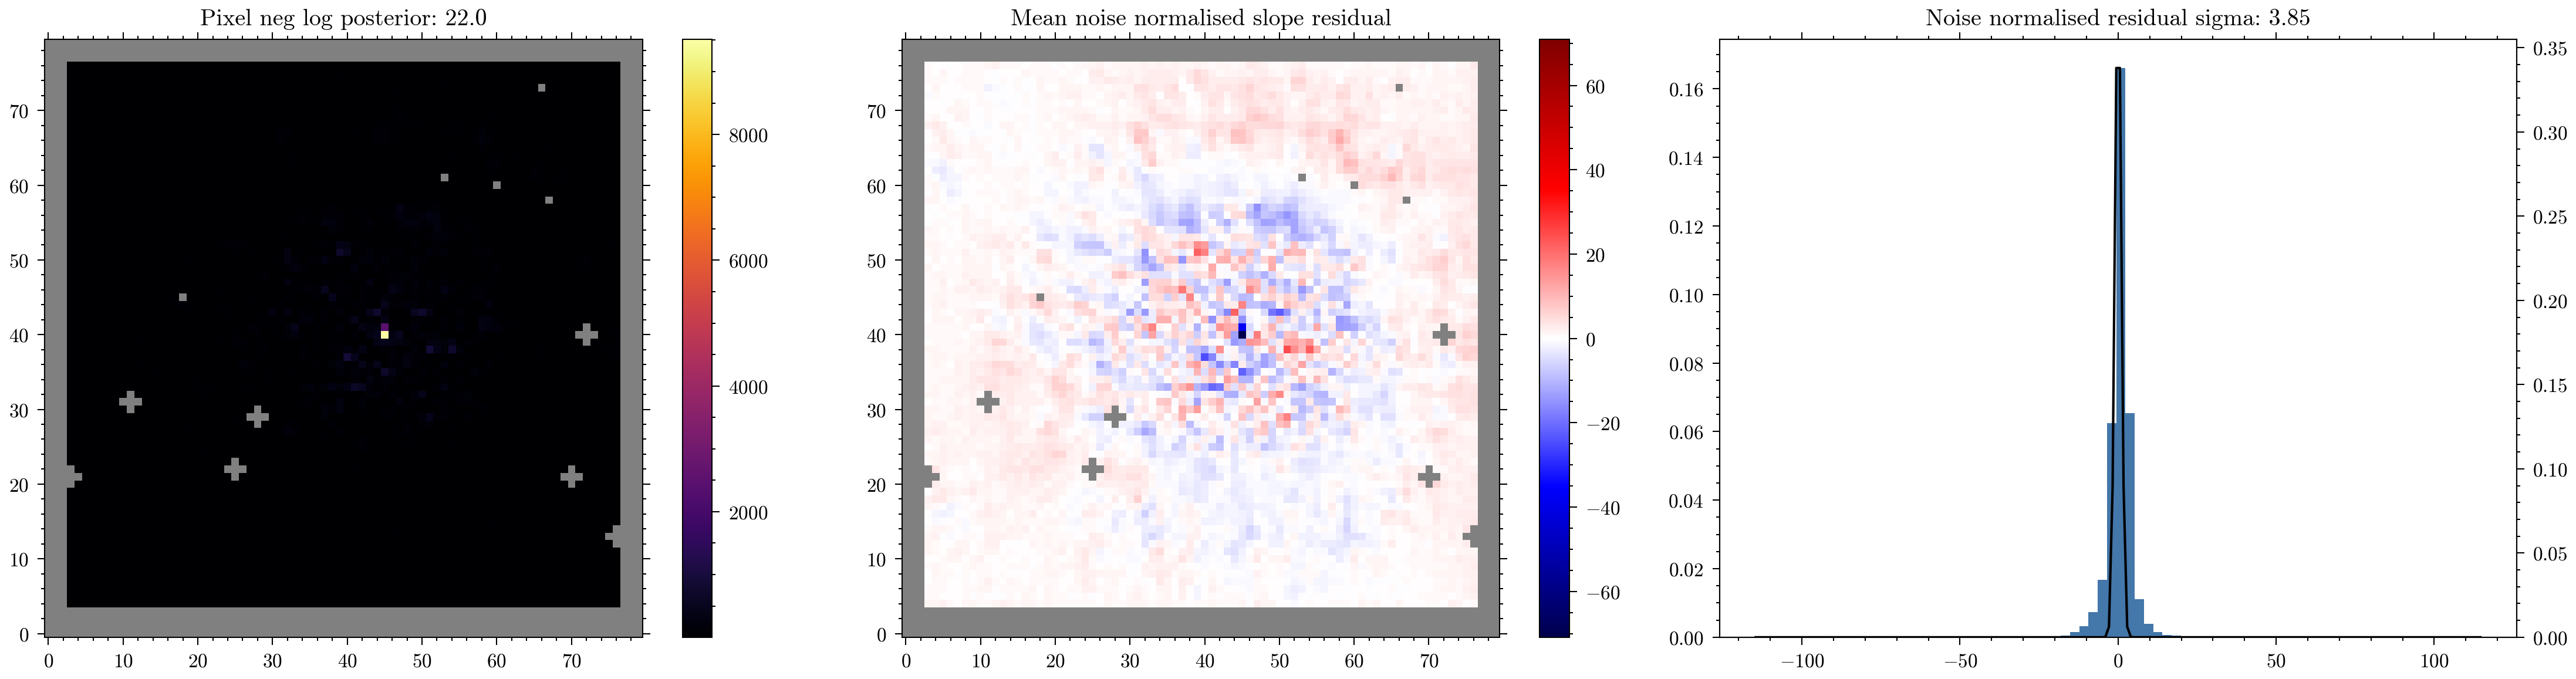

File 01260_103_02_03_3
Star NGC1068
Filter F480M
nints 91
ngroups 4



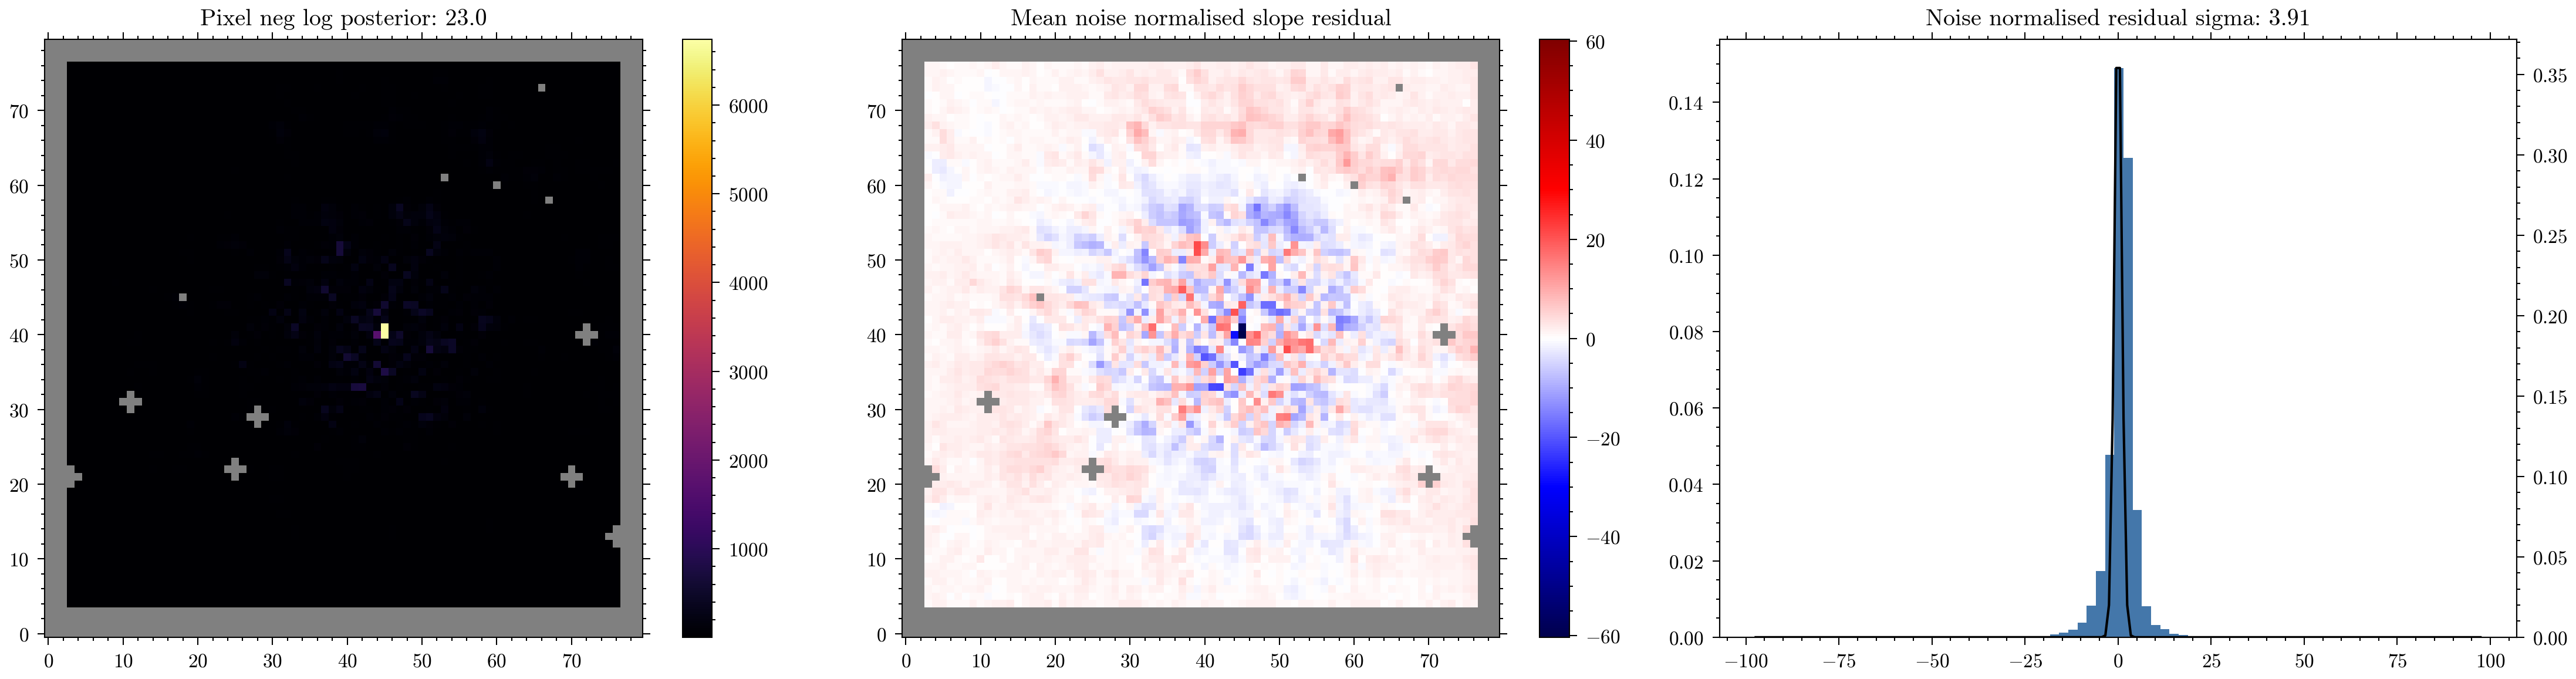

File 01260_103_02_03_4
Star NGC1068
Filter F480M
nints 91
ngroups 4



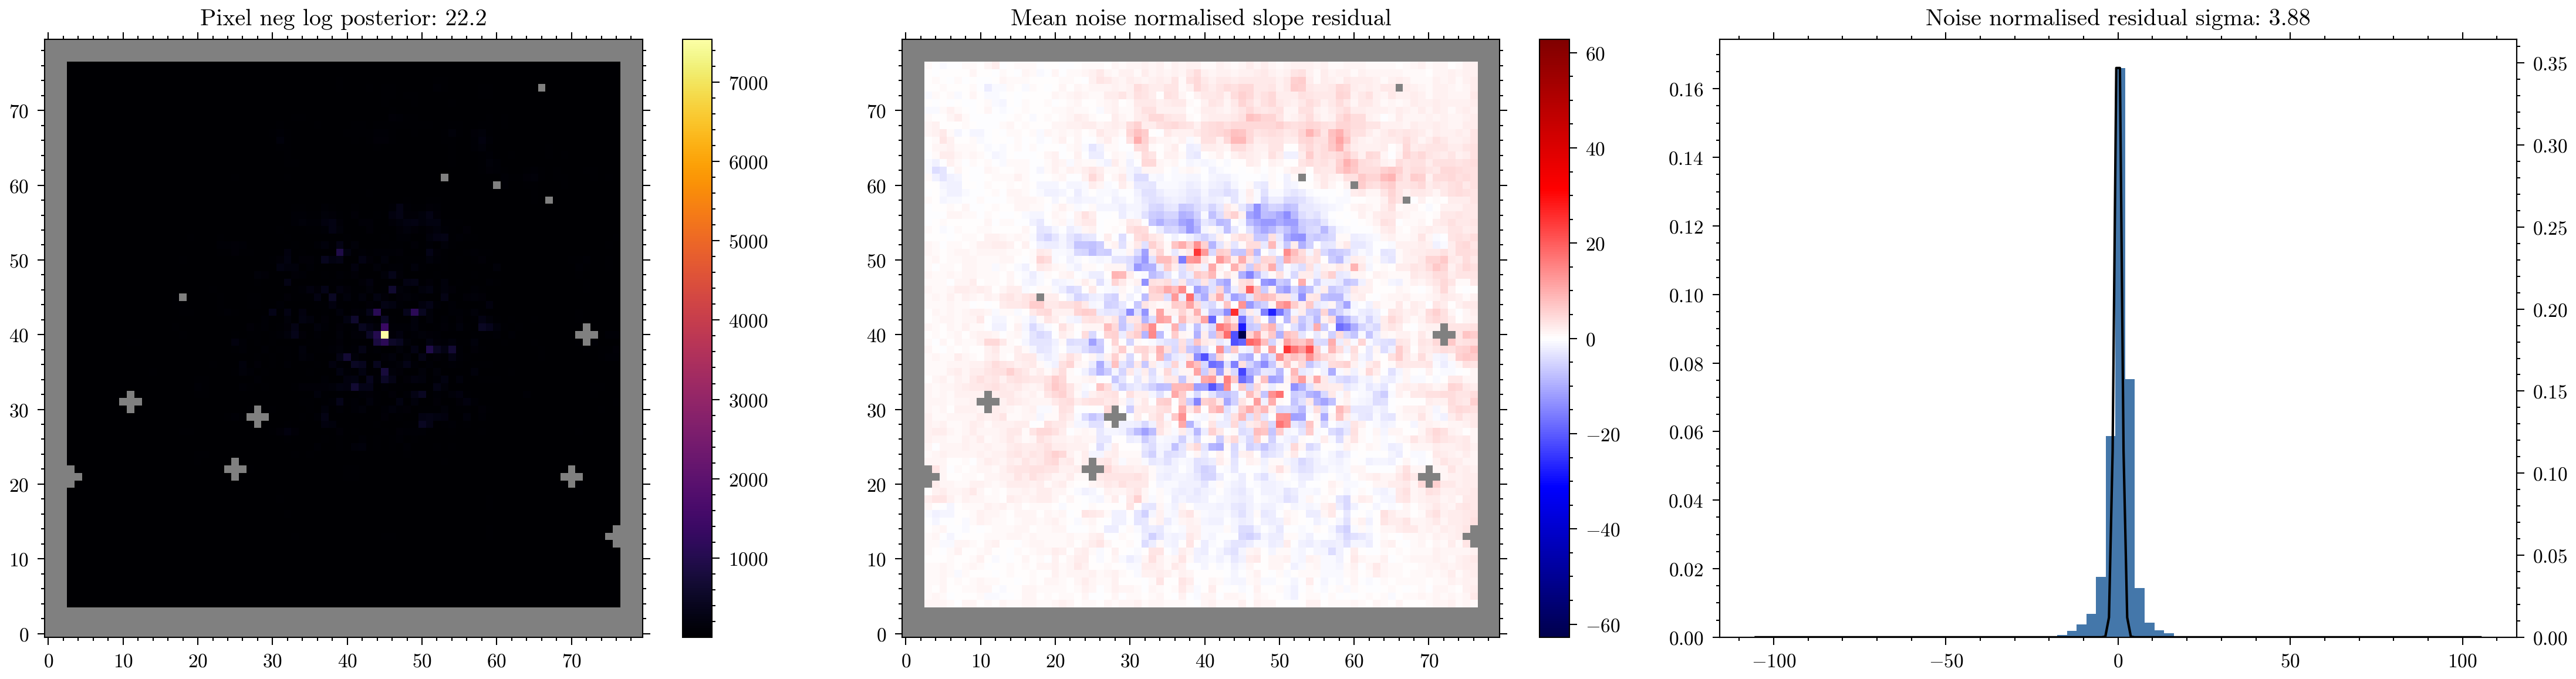

In [21]:
# np.save(init_state_cache + "F480M_120.npy", state.params)

flag = False
for exp in fits:

    try:
        if not flag:
            dist = final_model.get_distribution(exp)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.3,
                # model=final_model,
                vmin=None,
                # show_diff_lim=True,
                # vmax=io_peak_flux,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, final_model, exp, factor=0.5),
                cmap="afmhot_10u",
                power=0.3,
                roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            ax[0].set_title(f"NGC1068 - {exp.filter}")
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(save_dir + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
        flag = True
    except:
        continue


amigo.plotting.plot_losses(losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(histories)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        final_model,
        exp,
        # test_model,
    )